# exp12 — Melengkapi model pembanding PharmaSales

Notebook **pelapor**: membaca berkas hasil yang sudah ada, tidak melatih model,
tidak menulis ke `results/`, tidak mengimpor `src/experiments` maupun `tools`.

## 1. Ringkasan

**Pertanyaan yang dijawab.** RQ1 menyebut ARIMA, LSTM, *random forest*, GRNN dan XGBoost
sebagai model pembanding tunggal. Pada PharmaSales, protokol (exp01/exp02, exp05c) sudah
mencakup LR, GRNN, PNN, RBFNN dan XGBoost — tetapi ada tiga celah:

1. **Random Forest** hanya dipakai sebagai *pemodel residual* (exp08), tidak pernah sebagai
   peramal;
2. **LSTM** hanya dievaluasi pada Rossmann;
3. **ARIMA(5,1,0)** pada exp01/exp02 meramal seluruh blok uji secara **multi-langkah** dari
   ujung latih+validasi, sedangkan semua model lain meramal **bergulir satu langkah**
   (kontrak C7).

Butir ketiga adalah yang paling penting secara metodologis: ketimpangan itu **merugikan
ARIMA**, dan harus dihapus sebelum ARIMA dipakai sebagai pembanding di disertasi.

**Dipakai di mana.**

| Naskah | Bagian |
|---|---|
| Disertasi | Subbab 4.6.2, **Tabel 4.11** (baris Naive, ARIMA, Random Forest, LSTM, XGBoost, S₁) |
| Paper IJIES | **tidak dipakai** |

exp12 juga menjadi **fondasi kode** bagi exp13 dan exp14: keduanya mengimpor fungsi
`analyse()` dari skrip ini tanpa mengubahnya, sehingga ketiga eksperimen menghasilkan
ringkasan yang sebanding.

## 2. Lingkungan

In [1]:
# Notebook pelapor: HANYA MEMBACA.
# Tidak melatih model, tidak mengimpor src/experiments atau tools (agar TensorFlow
# tidak ikut termuat), dan tidak pernah menulis ke results/, data/ atau raw/.
%matplotlib inline
from pathlib import Path
import ast, json, hashlib, datetime, subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def cari_root(p: Path) -> Path:
    for c in [p, *p.parents]:
        if (c / "results").is_dir() and (c / "src" / "experiments").is_dir():
            return c
    raise RuntimeError("root repositori tidak ditemukan dari " + str(p))


ROOT = cari_root(Path.cwd().resolve())
RES = ROOT / "results"

pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_colwidth", 95)
pd.set_option("display.max_rows", 200)

print("Root repositori :", ROOT)
print("Folder hasil    :", RES.relative_to(ROOT),
      f"({sum(1 for f in RES.rglob('*') if f.is_file())} berkas)")
print("Dijalankan      :", datetime.datetime.now().strftime("%Y-%m-%d %H:%M"))


def idn(x, d=2, tanda=False):
    """Format angka gaya Indonesia (koma desimal, titik ribuan)."""
    s = f"{x:,.{d}f}".replace(",", "X").replace(".", ",").replace("X", ".")
    if tanda and x > 0:
        s = "+" + s
    return s.replace("-", "\u2212")


def baca(nama, **kw):
    """Baca satu berkas di results/ sebagai DataFrame. Read-only."""
    f = RES / nama
    if not f.exists():
        raise FileNotFoundError(f"{nama} tidak ada di results/")
    return pd.read_csv(f, **kw)


def potongan(relpath, nama=None, awal=None, akhir=None):
    """Tampilkan potongan kode dengan membaca berkas sebagai TEKS.

    Memakai ``ast`` untuk menemukan batas fungsi/konstanta, sehingga modul
    eksperimen tidak perlu diimpor.
    """
    f = ROOT / relpath
    teks = f.read_text(encoding="utf-8")
    baris = teks.splitlines()
    if nama is not None:
        pohon = ast.parse(teks)
        ketemu = False
        for n in ast.walk(pohon):
            if isinstance(n, (ast.FunctionDef, ast.AsyncFunctionDef, ast.ClassDef)) and n.name == nama:
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
            if isinstance(n, ast.Assign) and any(getattr(t, "id", None) == nama for t in n.targets):
                awal, akhir, ketemu = n.lineno, n.end_lineno, True
                break
        if not ketemu:
            raise KeyError(f"'{nama}' tidak ditemukan di {relpath}")
    awal = awal or 1
    akhir = akhir or len(baris)
    lebar = len(str(akhir))
    print(f"--- {relpath}:{awal}-{akhir} " + "-" * max(0, 74 - len(relpath)))
    for i in range(awal, akhir + 1):
        print(f"{str(i).rjust(lebar)} | {baris[i - 1]}")


def git(*args):
    """Jalankan perintah git read-only di root repositori."""
    try:
        r = subprocess.run(["git", *args], cwd=ROOT, capture_output=True, text=True, timeout=30)
        return r.stdout.strip() if r.returncode == 0 else ""
    except Exception:
        return ""


def asal(nama_meta=None, berkas_hasil=None, skrip=None, log=None):
    """Cetak asal-usul: meta.json, commit, dan log run bila ada."""
    if nama_meta:
        f = RES / nama_meta
        if f.exists():
            print("meta.json " + "-" * 60)
            print(json.dumps(json.loads(f.read_text(encoding="utf-8")), indent=2, ensure_ascii=False))
            print()
    for label, path in [("berkas hasil", berkas_hasil), ("skrip", skrip)]:
        if path:
            print(f"commit terakhir yang menyentuh {label} ({path})")
            print("  " + (git("log", "-1", "--date=short", "--format=%h  %ad  %s", "--", path) or "(tidak terbaca)"))
    if log:
        f = RES / "logs" / log
        print()
        if f.exists():
            print(f"results/logs/{log}  ({f.stat().st_size} bytes, "
                  f"ditulis {datetime.datetime.fromtimestamp(f.stat().st_mtime):%Y-%m-%d %H:%M})")
        else:
            print(f"results/logs/{log} tidak ada di klon ini (berkas *.log diabaikan git).")

Root repositori : I:\Shared drives\Riset S3\Experiment S3 Code\antgravity_riset\AR-LRX_hybrid-forecasting


Folder hasil    : results (179 berkas)
Dijalankan      : 2026-09-29 06:41


In [2]:
# Pembanding angka CSV terhadap angka yang tercetak di disertasi.
# Tidak ada angka yang dibetulkan di sini; ketidakcocokan hanya dilaporkan.
_cek = []


def cek(butir, nilai_csv, nilai_naskah, tol=0.005, d=4, rujukan=""):
    beda = abs(float(nilai_csv) - float(nilai_naskah))
    ok = beda <= tol
    _cek.append({
        "Butir": butir,
        "Rujukan naskah": rujukan,
        "Dari CSV": round(float(nilai_csv), d),
        "Di disertasi": float(nilai_naskah),
        "|selisih|": round(beda, 6),
        "Status": "COCOK" if ok else "TIDAK COCOK",
    })
    return ok


def laporan_cek():
    t = pd.DataFrame(_cek)
    n_ok = int((t.Status == "COCOK").sum())
    display(t)
    print()
    print(f"RINGKASAN: {n_ok} dari {len(t)} angka COCOK dengan naskah disertasi.")
    buruk = t[t.Status == "TIDAK COCOK"]
    if len(buruk):
        print()
        print("!" * 78)
        print("ADA ANGKA YANG TIDAK COCOK. Tidak dibetulkan di notebook ini.")
        print("Laporkan butir berikut sebelum notebook dipakai sebagai lampiran:")
        for _, r in buruk.iterrows():
            print(f"  - {r.Butir} ({r['Rujukan naskah']}): "
                  f"CSV {r['Dari CSV']} vs naskah {r['Di disertasi']}")
        print("!" * 78)
    else:
        print("Tidak ada selisih di luar toleransi pembulatan.")
    return t

## 3. Desain eksperimen

**ARIMA bergulir satu langkah.** Inilah pembetulan utamanya. Parameter ditaksir pada blok
yang sedang dilatih, lalu model di-*filter* atas deret teramati, sehingga setiap prediksi
hanya memakai pengamatan sampai $t-1$:

In [3]:
potongan("tools/exp12_pharma_baselines_completion.py", nama="arima_rolling_row")

--- tools/exp12_pharma_baselines_completion.py:69-89 --------------------------------
69 | def arima_rolling_row(d: P.Dataset) -> dict:
70 |     """One-step-ahead ARIMA: parameters from the fitting block, then filtering over
71 |     the observed series (no refitting inside the evaluation block)."""
72 |     from statsmodels.tsa.arima.model import ARIMA
73 |     t0 = time.time()
74 |     y = d.y
75 | 
76 |     def one_step(n_fit, n_end):
77 |         res = ARIMA(y[:n_fit], order=ORDER).fit()
78 |         full = ARIMA(y[:n_end], order=ORDER).filter(res.params)
79 |         return np.maximum(np.asarray(full.get_prediction(start=n_fit).predicted_mean), 0.0)
80 | 
81 |     val_pred = one_step(d.i_train_end, d.i_val_end)
82 |     test_pred = one_step(d.i_val_end, len(y))
83 |     row = {"model": "ARIMA(5,1,0) rolling 1-step", **d.describe(),
84 |            "params": str({"order": ORDER}), "n_grid": 1, "scaler": "none", "seed": P.SEED,
85 |            **P.compute_metrics(d.y_val, val_pred, 

**Grid Random Forest**, dikunci di muka:

In [4]:
potongan("tools/exp12_pharma_baselines_completion.py", nama="GRID_RF")

--- tools/exp12_pharma_baselines_completion.py:58-59 --------------------------------
58 | GRID_RF = {"n_estimators": [300], "max_depth": [None, 10], "min_samples_leaf": [1, 5],
59 |            "max_features": [1.0, "sqrt"]}


**LSTM** memakai pembangun Keras yang sudah diperkuat dari exp06b (target distandarkan pada
blok aktif, *early stopping* pada ekor kronologisnya), dengan grid lebar {64, 128, 256} —
inilah yang kemudian diperluas di exp13.

**Data dan kontrak.** 32 konfigurasi PharmaSales (2 granularitas × 8 kategori ATC × 2 set
fitur), 20 di antaranya berbeda. Kontrak C1–C8 tidak diubah: split kronologis 70/15/15,
penyetelan hanya pada validasi, refit pada latih+validasi, blok uji disentuh sekali,
seed 42.

## 4. Asal-usul hasil

In [5]:
RUN_EXPERIMENT = False

PERINTAH = [
    "python tools/exp12_pharma_baselines_completion.py",
]

if RUN_EXPERIMENT:
    for c in PERINTAH:
        print(">>", c)
        r = subprocess.run(c, shell=True, cwd=ROOT)
        print("   kode keluar:", r.returncode)
else:
    print("RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.")
    print()
    print("Perintah asli yang menghasilkan berkas di results/:")
    for c in PERINTAH:
        print("   ", c)
    print()
    print('Dijalankan 25 September 2026, setelah exp11.')

RUN_EXPERIMENT = False - eksperimen TIDAK dijalankan ulang.

Perintah asli yang menghasilkan berkas di results/:
    python tools/exp12_pharma_baselines_completion.py

Dijalankan 25 September 2026, setelah exp11.


In [6]:
asal(nama_meta="exp12_pharma_baselines.meta.json", berkas_hasil="results/exp12_pharma_baselines.csv", skrip="tools/exp12_pharma_baselines_completion.py")

meta.json ------------------------------------------------------------
{
  "experiment": "exp12_pharma_baselines",
  "n_rows": 256,
  "protocol": {
    "split_ratios": [
      0.7,
      0.15,
      0.15
    ],
    "tuning": "validation-only, refit on train+val",
    "feature_sets": [
      "A_lag1",
      "B_rich"
    ]
  },
  "environment": {
    "python": "3.10.11",
    "platform": "Windows-10-10.0.22621-SP0",
    "numpy": "2.2.6",
    "pandas": "2.3.3",
    "seed": "42",
    "sklearn": "1.7.2",
    "xgboost": "3.2.0",
    "statsmodels": "0.14.6"
  }
}

commit terakhir yang menyentuh berkas hasil (results/exp12_pharma_baselines.csv)


  69d4380  2026-09-25  Add exp12: rolling ARIMA, Random Forest and LSTM baselines on PharmaSales
commit terakhir yang menyentuh skrip (tools/exp12_pharma_baselines_completion.py)


  69d4380  2026-09-25  Add exp12: rolling ARIMA, Random Forest and LSTM baselines on PharmaSales


## 5. Hasil

### 5.1 Tabel 4.11 — bagian exp12

In [7]:
e12 = baca("exp12_pharma_baselines_summary.csv")
raw12 = baca("exp12_pharma_baselines.csv")
dm12 = baca("exp12_pharma_baselines_dm.csv")

d12 = e12[e12.scope == "distinct"].set_index(["reference", "granularity"])
URUT = ["Naive", "ARIMA(5,1,0) multi-step", "ARIMA(5,1,0) rolling 1-step",
        "Random Forest", "LSTM", "XGBoost", "S1 [linear]"]
rows = []
for k in URUT:
    a, b = d12.loc[(k, "daily")], d12.loc[(k, "weekly")]
    rows.append([k, f"{int(a.arlrx_wins)}/10", f"{int(a.sig_wins_bh)} / {int(a.sig_losses_bh)}",
                 round(a.pooled_pct, 2), f"{int(b.arlrx_wins)}/10",
                 f"{int(b.sig_wins_bh)} / {int(b.sig_losses_bh)}", round(b.pooled_pct, 2)])
display(pd.DataFrame(rows, columns=[
    "Pembanding", "Harian: AR-LRX menang", "Harian: sig. menang / kalah", "Harian: gabungan (%)",
    "Mingguan: AR-LRX menang", "Mingguan: sig. menang / kalah", "Mingguan: gabungan (%)"]))
print()
print("Gabungan negatif = AR-LRX lebih akurat. Signifikan = DM setelah koreksi Benjamini-Hochberg.")
print()
print(f"Model dalam berkas: {sorted(raw12.model.unique())}")
print(f"Baris              : {len(raw12)}")

,Pembanding,Harian: AR-LRX menang,Harian: sig. menang / kalah,Harian: gabungan (%),Mingguan: AR-LRX menang,Mingguan: sig. menang / kalah,Mingguan: gabungan (%)
0,Naive,10/10,10 / 0,-23.34,9/10,5 / 0,-12.94
1,"ARIMA(5,1,0) multi-step",6/10,4 / 1,-5.07,6/10,3 / 0,-15.53
2,"ARIMA(5,1,0) rolling 1-step",5/10,2 / 0,0.43,7/10,0 / 0,-1.86
3,Random Forest,9/10,0 / 0,-1.39,7/10,0 / 0,-1.19
4,LSTM,5/10,4 / 0,-0.68,5/10,1 / 0,-1.47
5,XGBoost,7/10,1 / 0,-0.54,8/10,0 / 0,-2.45
6,S1 [linear],2/10,0 / 0,0.18,2/10,0 / 0,0.38



Gabungan negatif = AR-LRX lebih akurat. Signifikan = DM setelah koreksi Benjamini-Hochberg.

Model dalam berkas: ['AR-LRX [linear]', 'ARIMA(5,1,0) multi-step', 'ARIMA(5,1,0) rolling 1-step', 'LSTM', 'Naive', 'Random Forest', 'S1 [linear]', 'XGBoost']
Baris              : 256


### 5.2 Efek pembetulan kontrak C7 pada ARIMA

Ini temuan metodologis terpenting exp12.

In [8]:
# Inti exp12: memperbaiki ketimpangan kontrak C7 pada ARIMA.
ms = d12.loc[("ARIMA(5,1,0) multi-step", "daily")].pooled_pct
rl = d12.loc[("ARIMA(5,1,0) rolling 1-step", "daily")].pooled_pct
msw = d12.loc[("ARIMA(5,1,0) multi-step", "weekly")].pooled_pct
rlw = d12.loc[("ARIMA(5,1,0) rolling 1-step", "weekly")].pooled_pct

print("AR-LRX terhadap ARIMA(5,1,0), gabungan atas 20 konfigurasi berbeda:")
print(f"  multi-langkah (seperti exp01) : harian {idn(ms,2,True)}%   mingguan {idn(msw,2,True)}%")
print(f"  bergulir satu langkah (C7)    : harian {idn(rl,2,True)}%   mingguan {idn(rlw,2,True)}%")
print()
print("Dengan perlakuan yang setara, ARIMA berubah dari pembanding yang tampak lemah")
print("menjadi pembanding yang kuat. Selisih perlakuannya:")
print(f"  harian   {idn(rl - ms, 2, True)} poin persen")
print(f"  mingguan {idn(rlw - msw, 2, True)} poin persen")

AR-LRX terhadap ARIMA(5,1,0), gabungan atas 20 konfigurasi berbeda:
  multi-langkah (seperti exp01) : harian −5,07%   mingguan −15,53%
  bergulir satu langkah (C7)    : harian +0,43%   mingguan −1,86%

Dengan perlakuan yang setara, ARIMA berubah dari pembanding yang tampak lemah
menjadi pembanding yang kuat. Selisih perlakuannya:
  harian   +5,50 poin persen
  mingguan +13,67 poin persen


### 5.3 Sebaran per konfigurasi

C:\Users\Admin1\AppData\Local\Temp\ipykernel_24864\1824333449.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=True, patch_artist=True, labels=[m[:16] for m in ref])
C:\Users\Admin1\AppData\Local\Temp\ipykernel_24864\1824333449.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, vert=True, patch_artist=True, labels=[m[:16] for m in ref])


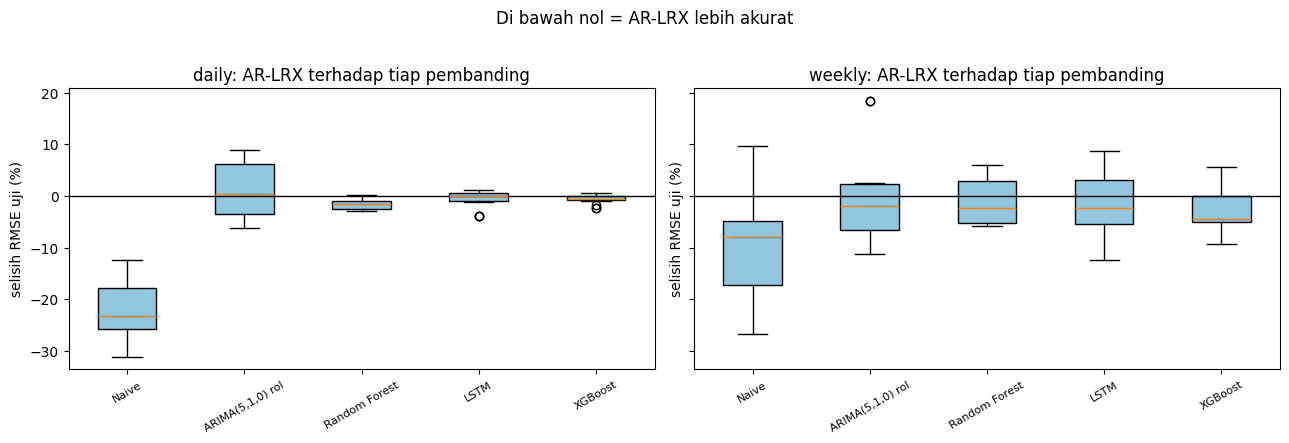

In [9]:
piv = raw12.pivot_table(index=["granularity", "category", "feature_set"],
                        columns="model", values="test_RMSE")
ref = [m for m in ["Naive", "ARIMA(5,1,0) rolling 1-step", "Random Forest", "LSTM", "XGBoost"]
       if m in piv.columns]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for ax, g in zip(axes, ["daily", "weekly"]):
    s = piv.xs(g, level="granularity")
    data = [100 * (s["AR-LRX [linear]"] / s[m] - 1).dropna() for m in ref]
    bp = ax.boxplot(data, vert=True, patch_artist=True, labels=[m[:16] for m in ref])
    for b in bp["boxes"]:
        b.set_facecolor("#92c5de")
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{g}: AR-LRX terhadap tiap pembanding")
    ax.set_ylabel("selisih RMSE uji (%)")
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
fig.suptitle("Di bawah nol = AR-LRX lebih akurat", y=1.02)
fig.tight_layout(); plt.show()

## 6. Cek kecocokan dengan angka disertasi

In [10]:
cek("Tabel 4.11 ARIMA multi-langkah harian (%)",
    d12.loc[("ARIMA(5,1,0) multi-step", "daily")].pooled_pct, -5.07, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 ARIMA multi-langkah mingguan (%)",
    d12.loc[("ARIMA(5,1,0) multi-step", "weekly")].pooled_pct, -15.53, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 ARIMA bergulir harian (%)",
    d12.loc[("ARIMA(5,1,0) rolling 1-step", "daily")].pooled_pct, 0.43, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 ARIMA bergulir harian: menang signifikan",
    d12.loc[("ARIMA(5,1,0) rolling 1-step", "daily")].sig_wins_bh, 2, tol=0, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 ARIMA bergulir mingguan (%)",
    d12.loc[("ARIMA(5,1,0) rolling 1-step", "weekly")].pooled_pct, -1.86, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 ARIMA bergulir mingguan: menang signifikan",
    d12.loc[("ARIMA(5,1,0) rolling 1-step", "weekly")].sig_wins_bh, 0, tol=0, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 Random Forest harian (%)",
    d12.loc[("Random Forest", "daily")].pooled_pct, -1.39, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 Random Forest mingguan (%)",
    d12.loc[("Random Forest", "weekly")].pooled_pct, -1.19, tol=0.005, rujukan="Subbab 4.6.2")
cek("Tabel 4.11 Naive harian (%)", d12.loc[("Naive", "daily")].pooled_pct, -23.34,
    tol=0.005, rujukan="Tabel 4.11")
cek("Tabel 4.11 XGBoost harian (%)", d12.loc[("XGBoost", "daily")].pooled_pct, -0.54,
    tol=0.005, rujukan="Tabel 4.11")
cek("Tabel 4.11 XGBoost mingguan (%)", d12.loc[("XGBoost", "weekly")].pooled_pct, -2.45,
    tol=0.005, rujukan="Tabel 4.11")
cek("Tabel 4.11 S1 [linear] harian (%)", d12.loc[("S1 [linear]", "daily")].pooled_pct, 0.18,
    tol=0.005, rujukan="Tabel 4.11")
cek("Tabel 4.11 S1 [linear] mingguan (%)", d12.loc[("S1 [linear]", "weekly")].pooled_pct, 0.38,
    tol=0.005, rujukan="Tabel 4.11")
cek("Jumlah konfigurasi berbeda per granularitas",
    d12.loc[("Naive", "daily")].n, 10, tol=0, rujukan="judul Tabel 4.11")

hasil_cek = laporan_cek()

,Butir,Rujukan naskah,Dari CSV,Di disertasi,|selisih|,Status
0,Tabel 4.11 ARIMA multi-langkah harian (%),Subbab 4.6.2,-5.0659,-5.07,0.004136,COCOK
1,Tabel 4.11 ARIMA multi-langkah mingguan (%),Subbab 4.6.2,-15.5340,-15.53,0.004030,COCOK
2,Tabel 4.11 ARIMA bergulir harian (%),Subbab 4.6.2,0.4295,0.43,0.000494,COCOK
3,Tabel 4.11 ARIMA bergulir harian: menang signifikan,Subbab 4.6.2,2.0000,2.00,0.000000,COCOK
4,Tabel 4.11 ARIMA bergulir mingguan (%),Subbab 4.6.2,-1.8610,-1.86,0.000967,COCOK
5,Tabel 4.11 ARIMA bergulir mingguan: menang signifikan,Subbab 4.6.2,0.0000,0.00,0.000000,COCOK
6,Tabel 4.11 Random Forest harian (%),Subbab 4.6.2,-1.3854,-1.39,0.004640,COCOK
7,Tabel 4.11 Random Forest mingguan (%),Subbab 4.6.2,-1.1866,-1.19,0.003422,COCOK
8,Tabel 4.11 Naive harian (%),Tabel 4.11,-23.3389,-23.34,0.001142,COCOK
9,Tabel 4.11 XGBoost harian (%),Tabel 4.11,-0.5395,-0.54,0.000480,COCOK



RINGKASAN: 14 dari 14 angka COCOK dengan naskah disertasi.
Tidak ada selisih di luar toleransi pembulatan.


## 7. Interpretasi dan keterbatasan

**Pembetulan kontrak C7 mengubah kesimpulan tentang ARIMA secara drastis.** Versi
multi-langkah membuat ARIMA tampak jauh lebih buruk (selisih gabungan −5,07% harian dan
−15,53% mingguan menguntungkan AR-LRX). Dengan perlakuan yang setara, ARIMA bergulir menjadi
pembanding yang **kuat**: pada data harian AR-LRX justru 0,43% lebih buruk secara gabungan,
walaupun menang signifikan pada dua konfigurasi; pada data mingguan AR-LRX 1,86% lebih baik
tanpa kemenangan signifikan.

**Ini adalah koreksi yang merugikan hipotesis penulis sendiri**, dan justru itu yang membuat
perbandingannya dapat dipertanggungjawabkan. Kalau exp12 tidak dijalankan, disertasi akan
mengklaim keunggulan 5–15% atas ARIMA yang sebenarnya artefak perlakuan.

**Terhadap model pembanding lain**, AR-LRX sedikit lebih akurat daripada *random forest*
(−1,39% dan −1,19%), LSTM, dan XGBoost, tetapi selisihnya kecil. Terhadap naive, selisihnya
besar (−23,34% harian).

**Keterbatasan.**

1. ARIMA memakai order (5,1,0) tetap, bukan pemilihan order otomatis gaya `auto.arima`.
   Ini warisan exp01 dan dipertahankan agar sebanding.
2. LSTM di sini memakai grid {64, 128, 256}; batas grid itu baru diuji di exp13.
3. Pemulusan eksponensial belum ada di exp12 — ditambahkan di exp14, dan ternyata
   mengalahkan AR-LRX pada data harian.
4. Satu pembagian data, satu seed.

## 8. Pertanyaan yang mungkin diajukan promotor

**1. "Mengapa ARIMA di exp01 dijalankan berbeda dari model lain?"**
Itu cacat warisan dari kerangka lama, dan exp12 ada justru untuk memperbaikinya.
Pemeriksaan kode exp01 menunjukkan ARIMA(5,1,0) meramal seluruh blok uji multi-langkah dari
ujung latih+validasi, sedangkan model lain meramal bergulir satu langkah. Itu melanggar
kontrak C7 dan merugikan ARIMA.

**2. "Setelah dibetulkan, ARIMA mengalahkan AR-LRX pada data harian. Apakah itu tidak
melemahkan disertasi?"**
Klaim atas ARIMA memang melemah, dan angkanya dilaporkan apa adanya di Subbab 4.6.2, yaitu
+0,43% lebih buruk secara gabungan. Klaim AR-LRX pada data obat bersifat bersyarat dan
kecil, sedangkan klaim yang kuat berada pada Rossmann.

**3. "Mengapa Random Forest tidak ada sejak exp01?"**
Sebelum exp12, Random Forest hanya dipakai sebagai model residual di exp08 dan tidak pernah
dievaluasi sebagai model prediksi tunggal pada PharmaSales. exp12 melengkapi kekurangan itu.

**4. "Apakah exp13 dan exp14 memakai kode analisis yang sama?"**
Ya, keduanya mengimpor `analyse()` dari skrip exp12 tanpa perubahan. Itu sebabnya baris
`S1 [linear]` dan `ARIMA bergulir` pada ketiga eksperimen identik sampai digit terakhir —
kesamaannya diperiksa di notebook pelapor exp14.

**5. "Mengapa hanya 20 dari 32 konfigurasi yang dilaporkan pada ringkasan gabungan?"**
Karena ketika jumlah lag yang dipilih dari PACF data latih sama dengan 1, set fitur `B_rich`
berubah menjadi identik dengan `A_lag1`, sehingga keduanya model yang sama. Pada pembagian
utama itu terjadi pada 12 dari 16 pasangan kategori × granularitas. Melaporkan 32 akan
menghitung ganda.